# 🧬 Mapping the Chemical Landscape of GLP-1R Compounds
## Unsupervised Learning for Drug-Likeness Profiling

## 📦 Importing Required Libraries

In this section, we import all the necessary libraries for data analysis, visualization, and machine learning.

- **pandas** → data manipulation and analysis  
- **matplotlib & seaborn** → data visualization  
- **scikit-learn** → preprocessing, dimensionality reduction, and clustering  
- **scipy** → statistical functions  
- **warnings** → suppress unnecessary warnings for cleaner output  

In [58]:
# ==============================
# 📦 Import Required Libraries
# ==============================

# Ignore unnecessary warnings for cleaner notebook output
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical function
from scipy.stats.mstats import trimmed_var

# Machine learning tools
from sklearn.preprocessing import StandardScaler      # Feature scaling
from sklearn.decomposition import PCA                # Dimensionality reduction
from sklearn.cluster import KMeans                   # Clustering algorithm
from sklearn.metrics import silhouette_score         # Cluster evaluation
from sklearn.pipeline import make_pipeline           # Pipeline creation

## 📂 Data Wrangling Function

We define a function `wrangle()` to load and prepare the dataset.


In [57]:
def wrangle(filepath):
    df = pd.read_csv(filepath)

    return df

In [7]:
df = wrangle("https://raw.githubusercontent.com/ojumoolatimi/GLP1R-Ligand-Clustering/refs/heads/main/GLP1R_EGFR_drug_compounds.csv")

print(df.shape)
df.head()

(500, 14)


,ChEMBL ID,Molecular Weight,AlogP,Polar Surface Area,HBA,HBD,#Rotatable Bonds,QED Weighted,Aromatic Rings,Heavy Atoms,Np Likeness Score,#RO5 Violations,Bioactivities,Max Phase
0,CHEMBL4979177,439.61,4.47,145.97,3,2,6,0.9752,2,39,-2.253,0,159,4
1,CHEMBL2571492,363.41,6.24,126.99,3,5,4,0.5607,1,33,-2.765,1,153,1
2,CHEMBL1958626,457.72,0.28,92.39,4,4,5,0.7714,2,41,0.099,0,103,4
3,CHEMBL5394512,562.76,3.81,64.12,2,1,2,0.7732,2,51,-0.650,1,24,3
4,CHEMBL2605777,351.90,1.63,117.93,8,2,5,0.4690,2,31,-1.004,0,65,3


## 🔍 Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand its structure, quality, and key characteristics.

We will:
- Inspect the shape of the data  
- Examine data types  
- Check for missing values  
- Generate summary statistics  

In [16]:
df.isna().sum()


,0
ChEMBL ID,0
Molecular Weight,0
AlogP,0
Polar Surface Area,0
HBA,0
HBD,0
#Rotatable Bonds,0
QED Weighted,0
Aromatic Rings,0
Heavy Atoms,0


In [59]:
df.describe()

,Molecular Weight,AlogP,Polar Surface Area,HBA,HBD,#Rotatable Bonds,QED Weighted,Aromatic Rings,Heavy Atoms,Np Likeness Score,#RO5 Violations,Bioactivities,Max Phase
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,381.492820,2.853120,94.510580,4.444000,1.954000,4.822000,0.719960,1.940000,34.180000,-0.866146,0.26200,101.520000,1.176000
std,115.619373,1.749527,39.965288,2.056044,1.326425,1.906196,0.153410,1.400115,10.506015,1.194025,0.48768,57.563467,1.414576
min,150.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.156700,0.000000,13.000000,-3.762000,0.00000,1.000000,0.000000
25%,295.960000,1.725000,65.907500,3.000000,1.000000,4.000000,0.615675,1.000000,26.000000,-1.747500,0.00000,50.750000,0.000000
50%,381.535000,2.850000,94.790000,4.000000,2.000000,5.000000,0.736400,2.000000,34.000000,-0.818000,0.00000,100.500000,0.000000
75%,456.415000,3.972500,120.187500,6.000000,3.000000,6.000000,0.841525,3.000000,41.000000,-0.080750,0.00000,154.000000,2.000000
max,800.000000,7.000000,194.070000,11.000000,6.000000,14.000000,0.997000,6.000000,70.000000,2.000000,2.00000,199.000000,4.000000


### 📊 Feature Variability Analysis

In this step, we calculate the variance of numerical features to identify which variables show the most spread (variability).

- High variance → more information / stronger signal  
- Low variance → less useful for modeling  

We extract the **top 10 features with the highest variance**.

In [14]:
top_ten_var = df.select_dtypes(include=['number']).var().sort_values().tail(10)
print("top_ten_var type:", type(top_ten_var))
print("top_ten_var shape:", top_ten_var.shape)
top_ten_var

top_ten_var type: <class 'pandas.core.series.Series'>
top_ten_var shape: (10,)


,0
HBD,1.759403
Aromatic Rings,1.960321
Max Phase,2.001026
AlogP,3.060844
#Rotatable Bonds,3.633583
HBA,4.227319
Heavy Atoms,110.376353
Polar Surface Area,1597.224234
Bioactivities,3313.552705
Molecular Weight,13367.839492


### 📊 Visualization of Feature Variance

We visualize the top 10 features with the highest variance using a horizontal bar chart.

- A **log scale** is applied to better compare features with large differences in variance  
- This helps highlight which features dominate in terms of variability  

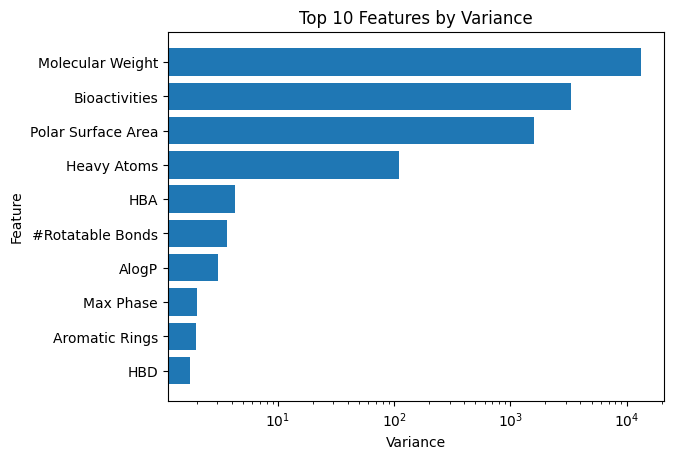

In [22]:
# Create horizontal bar chart of `top_ten_var`
plt.barh(top_ten_var.index, top_ten_var.values)
plt.xscale('log')
plt.xlabel("Variance")
plt.ylabel("Feature")
plt.title("Top 10 Features by Variance")
plt.show()
#

### 📊 Robust Feature Variability (Trimmed Variance)

In addition to standard variance, we compute **trimmed variance**, which reduces the effect of extreme values (outliers).

- Regular variance → sensitive to outliers  
- Trimmed variance → more robust and reliable  

This helps us identify features with high variability **without being misled by extreme values**.

In [19]:
top_ten_trimmed_var = df.select_dtypes(include=['number']).apply(trimmed_var).sort_values().tail(10)
print("top_ten_trimmed_var type:", type(top_ten_trimmed_var))
print("top_ten_trimmed_var shape:", top_ten_trimmed_var.shape)
top_ten_trimmed_var

top_ten_trimmed_var type: <class 'pandas.core.series.Series'>
top_ten_trimmed_var shape: (10,)


,0
HBD,0.915944
Aromatic Rings,1.070400
Max Phase,1.284100
AlogP,1.331385
#Rotatable Bonds,1.510744
HBA,1.950244
Heavy Atoms,49.457244
Polar Surface Area,719.654543
Bioactivities,2149.837600
Molecular Weight,5946.317867


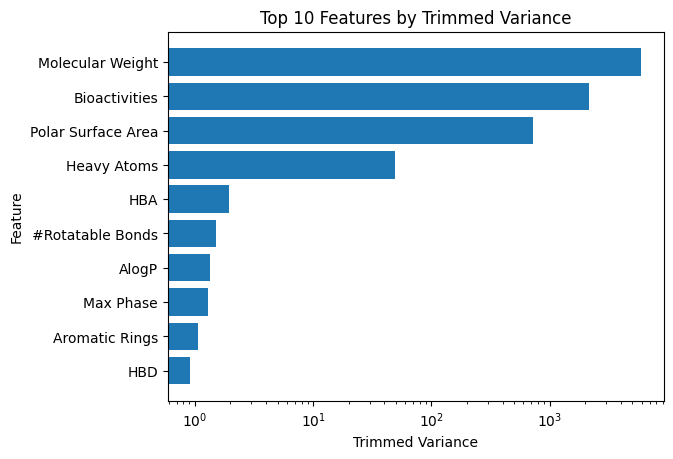

In [21]:
# Create horizontal bar chart of `top_ten_trimmed_var`
plt.barh(top_ten_trimmed_var.index, top_ten_trimmed_var)
plt.xscale('log')
plt.xlabel("Trimmed Variance")
plt.ylabel("Feature")
plt.title("Top 10 Features by Trimmed Variance")
plt.show()

In [60]:
# ==============================
# 🎯 Select Top 5 High-Variance Features
# ==============================

# Extract top 5 features with highest variance
high_var_cols = top_ten_var.tail(5).index.tolist()

# Display selected features
print("Selected high-variance features:")
print(high_var_cols)

Selected high-variance features:
['HBA', 'Heavy Atoms', 'Polar Surface Area', 'Bioactivities', 'Molecular Weight']


### ✂️ Feature Splitting for Modeling

At this stage, we have split our dataset to select only the high-variance features.

- `X` contains the features we will use to **build and train our model**.  
- This ensures we focus on the **most informative variables**, reducing noise and improving performance.  

Next steps will include:
1. **Scaling** the features for uniformity  
2. Applying **PCA** for dimensionality reduction  
3. Performing **KMeans clustering** to uncover patterns in the data

In [26]:
X = df[high_var_cols]

print('X type:', type(X))
print('X shape:', X.shape)
X.head()

X type: <class 'pandas.core.frame.DataFrame'>
X shape: (500, 5)


,HBA,Heavy Atoms,Polar Surface Area,Bioactivities,Molecular Weight
0,3,39,145.97,159,439.61
1,3,33,126.99,153,363.41
2,4,41,92.39,103,457.72
3,2,51,64.12,24,562.76
4,8,31,117.93,65,351.90


## 🤖 Building the Clustering Model

We use **KMeans clustering** to identify patterns in the dataset using the high-variance features.  

Steps:
1. **Scale the features** using `StandardScaler` to ensure all features contribute equally.  
2. Loop over different numbers of clusters (`n_clusters = 2 to 12`) to find the optimal number.  
3. For each `k`, calculate:
   - **Inertia (sum of squared distances)** → lower is better  
   - **Silhouette score** → measures how well-separated the clusters are (closer to 1 is better)  

In [30]:
n_clusters = range(2, 13)
inertia_errors = []
silhouette_scores = []

#create a for loop for n_clusters
for k in n_clusters:
    #build model
    model = make_pipeline(
        StandardScaler(),
        KMeans(
            n_clusters=k,
            random_state=42
        )
    )

    #train model
    model.fit(X)

    #calculate inertia error
    inertia_errors.append(model.named_steps['kmeans'].inertia_)

    #build model for silhouette scores
    silhouette_scores.append(silhouette_score(X, model.named_steps['kmeans'].labels_))

print("inertia_errors type:", type(inertia_errors))
print("inertia_errors len:", len(inertia_errors))
print("Inertia:", inertia_errors)
print()
print("silhouette_scores type:", type(silhouette_scores))
print("silhouette_scores len:", len(silhouette_scores))
print("Silhouette Scores:", silhouette_scores)

inertia_errors type: <class 'list'>
inertia_errors len: 11
Inertia: [1849.79715413238, 1606.575865157658, 1467.9215914644537, 1281.9231811910306, 1180.6809450896062, 1093.8867542167177, 997.5196053205153, 963.4164512090211, 879.230052632431, 850.7847070569708, 811.3728136136413]

silhouette_scores type: <class 'list'>
silhouette_scores len: 11
Silhouette Scores: [np.float64(0.3773955740361953), np.float64(0.2891864931854018), np.float64(0.12575575355111107), np.float64(0.151069416381622), np.float64(0.1502908443309992), np.float64(0.1339003411451107), np.float64(0.10306223602854908), np.float64(0.132859083022417), np.float64(0.10713230060445854), np.float64(0.0956067772739662), np.float64(0.09564895705474522)]


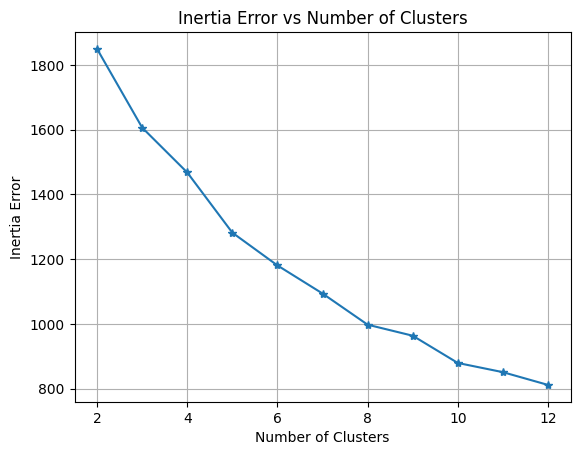

In [35]:
# Create line plot of `inertia_errors` vs `n_clusters`
plt.plot(n_clusters, inertia_errors, marker = '*')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia Error")
plt.title("Inertia Error vs Number of Clusters")
plt.grid()
plt.show()
#

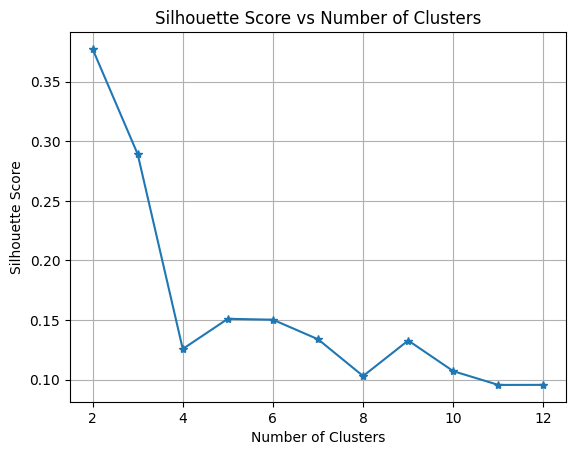

In [34]:
# Create a line plot of `silhouette_scores` vs `n_clusters
plt.plot(n_clusters, silhouette_scores, marker = '*')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid()
plt.show()
#

## 🏁 Final KMeans Model

Based on the previous analysis (inertia and silhouette scores), we select **5 clusters** for the final KMeans model.  

Steps:
1. **Scale the features** using `StandardScaler`  
2. **Fit KMeans** with `n_clusters=5`  
3. This model will be used to **assign cluster labels** to the data for further analysis

In [40]:
#build final model
final_model = make_pipeline(
    StandardScaler(),
    KMeans(
        n_clusters=5,
        random_state=42
        )
    )


  #train the model
final_model.fit(X)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=5, random_state=42))])

## 📢 Communicating Cluster Results

Now that the final KMeans model is trained, we will:

1. **Assign cluster labels** to each observation  
2. **Summarize cluster characteristics** by calculating the mean of each feature per cluster  

This helps us understand **what each cluster represents** and how they differ from one another.

In [42]:
labels = final_model.named_steps['kmeans'].labels_
print("labels type:", type(labels))
print("labels shape:", labels.shape)
labels[:5]

labels type: <class 'numpy.ndarray'>
labels shape: (500,)


array([4, 1, 2, 2, 0], dtype=int32)

In [44]:
xgb = X.groupby(labels).mean()
print("xgb type:", type(xgb))
print("xgb shape:", xgb.shape)
xgb

xgb type: <class 'pandas.core.frame.DataFrame'>
xgb shape: (5, 5)


,HBA,Heavy Atoms,Polar Surface Area,Bioactivities,Molecular Weight
0,6.544444,35.322222,82.513000,56.944444,394.546333
1,4.530973,26.203540,100.441416,159.176991,293.405133
2,4.271028,44.859813,66.574112,134.822430,498.737196
3,3.306306,24.729730,94.817658,54.990991,277.729099
4,3.759494,43.101266,137.101899,90.101266,479.615823


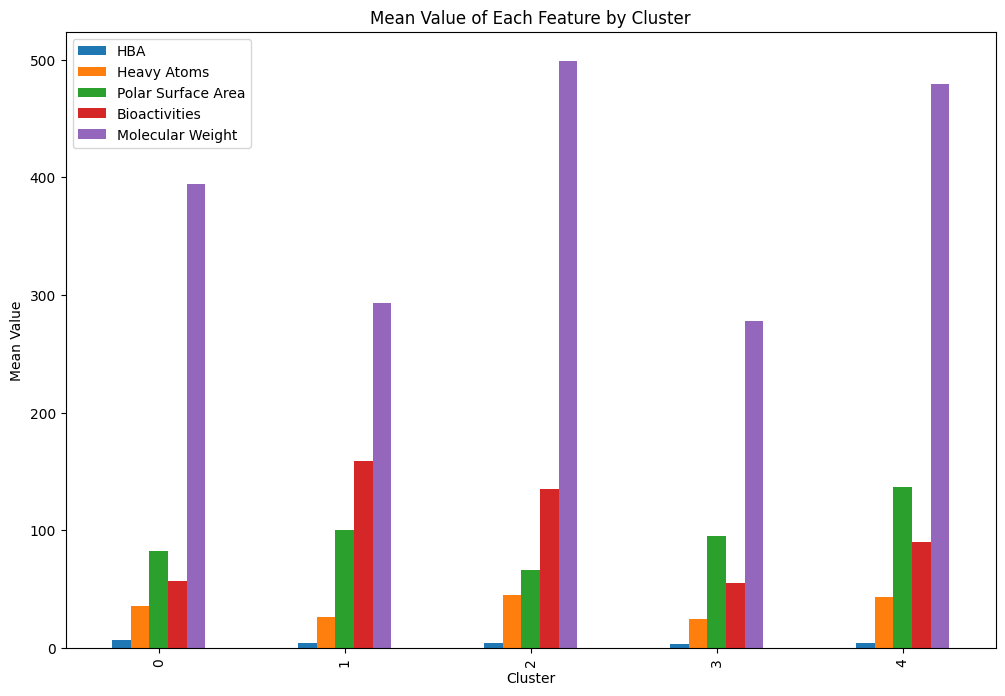

In [45]:
# Create side-by-side bar chart of `xgb
xgb.plot(kind='bar', figsize=(12, 8))
plt.xlabel("Cluster")
plt.ylabel("Mean Value")
plt.title("Mean Value of Each Feature by Cluster")

plt.show()


## 🔬 Cluster Analysis — Mean Feature Values per Cluster

This section interprets the unsupervised model's output.
The chart shows the **mean value of 5 molecular features** across 5 clusters (0–4):
`HBA`, `Heavy Atoms`, `Polar Surface Area`, `Bioactivities`, and `Molecular Weight`.

---

### Cluster 0 — Lightweight, Low-Complexity Molecules
- **Molecular Weight** (~390) is the dominant feature, but lowest across all clusters
- All other features are low — suggesting small, structurally simple molecules
- Low bioactivity implies minimal biological interaction

---

### Cluster 1 — Moderately Complex, High Bioactivity
- **Bioactivities** (~155) and **Polar Surface Area** (~100) are notably elevated
- **Molecular Weight** (~290) is moderate
- These molecules are chemically active with decent surface exposure
- > 💊 Potentially strong drug candidates

---

### Cluster 2 — Heaviest Molecules, Moderate Bioactivity
- **Molecular Weight** (~490) is the highest across all clusters
- **Heavy Atoms** (~55) and **Bioactivities** (130) are also elevated
- These are the **largest, most complex** molecules in the dataset

---

### Cluster 3 — Low Activity, Medium Weight
- **Bioactivities** are the lowest of all clusters
- **Polar Surface Area** (~95) remains moderate
- **Molecular Weight** (~275) is the lowest here
- Likely structurally simple molecules with weak biological interaction

---

### Cluster 4 — Balanced, High-Surface Molecules
- **Heavy Atoms** (~135) and **Polar Surface Area** are the highest here
- **Molecular Weight** (~465) is the second highest
- Large molecules with high surface exposure — possibly flexible or multi-ring structures

---

### 📌 Summary
| Cluster | Key Trait | Drug Relevance |
|---------|-----------|----------------|
| 0 | Small & simple | Low priority |
| 1 | High bioactivity | ✅ High priority |
| 2 | Heaviest molecules | Moderate priority |
| 3 | Low activity | Low priority |
| 4 | High surface area | Investigate further |

> **Note:** The model successfully separated molecules by size and bioactivity —
> useful for drug discovery prioritization.

In [49]:
#instantiate transformer
pca = PCA(
    n_components=2,
    random_state=42
)

#fit and transform
components = pca.fit_transform(X
)

X_PCA = pd.DataFrame(
    components,
    columns=['PC1', 'PC2']
)


print("X_PCA type:", type(X_PCA))
print("X_PCA shape:", X_PCA.shape)
X_PCA.head()

X_PCA type: <class 'pandas.core.frame.DataFrame'>
X_PCA shape: (500, 2)


,PC1,PC2
0,58.748182,55.702184
1,-17.356394,51.968658
2,76.570123,-0.772093
3,180.349726,-82.823266
4,-31.360404,-35.645990


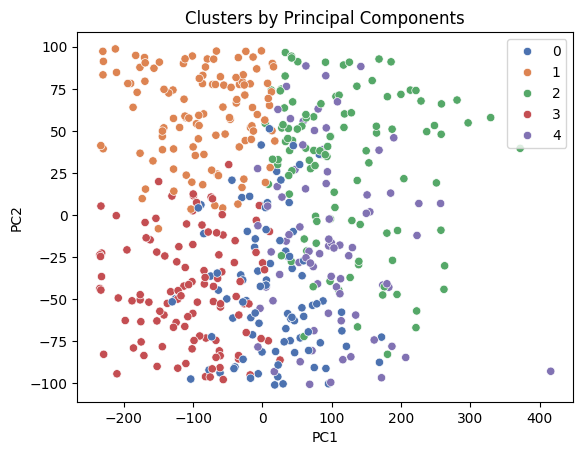

In [54]:
#create scatter plot
sns.scatterplot(x=X_PCA.iloc[:, 0], y=X_PCA.iloc[:, 1], hue=labels, palette = 'deep')
plt.title("Clusters by Principal Components")
plt.show()


#  Conclusions and Feature Glossary

### **Project Summary**
Through unsupervised learning, this notebook mapped the chemical landscape of **GLP-1R compounds. By applying PCA and K-Means clustering to 11 molecular descriptors, we identified distinct structural "niches" that correlate with drug-likeness and clinical progression.

---

### **Data Dictionary (Feature Glossary)**

#### **Model Input Features**
* **Molecular Weight:** Total mass of the molecule ($g/mol$). Represents molecular size.
* **AlogP:** The lipophilicity index. Measures how well a drug dissolves in fats vs. water, affecting membrane permeability.
* **Polar Surface Area (PSA):** Sum of the surface of all polar atoms. Critical for predicting drug transport.
* **HBA / HBD:** Hydrogen Bond Acceptors and Donors. Measures the molecule's ability to form hydrogen bonds.
* **#Rotatable Bonds:** A measure of molecular flexibility. High flexibility often reduces oral bioavailability.
* **QED Weighted:** Quantitative Estimate of Drug-likeness. A score (0 to 1) indicating how "medicine-like" a molecule is.
* **Aromatic Rings:** The count of resonance-stabilized rings. These influence receptor binding orientation.
* **Heavy Atoms:** Count of all non-hydrogen atoms in the structure.
* **Np Likeness Score:** Measures how closely a molecule mimics a natural product vs. a synthetic one.
* **#RO5 Violations:** Count of violations of Lipinski’s Rule of Five. Predicts poor absorption if >1.

#### **Metadata & Labels**
* **ChEMBL ID:** Unique identifier for the compound.
* **Bioactivities:** Number of experimental assays recorded for the compound.
* **Max Phase:** Highest clinical trial stage reached (0: Discovery, 4: Approved).

In [ ]:
_